In [50]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv


# **PS2**

# **STEP 1 — Imports**

In [51]:

import os
import gc
import math
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.stats import mannwhitneyu

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

# **STEP 2 — Paths and settings**

In [52]:

BASE_PATH = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset"

FEATURES_PATH = os.path.join(BASE_PATH, "elliptic_txs_features.csv")
CLASSES_PATH  = os.path.join(BASE_PATH, "elliptic_txs_classes.csv")
EDGES_PATH    = os.path.join(BASE_PATH, "elliptic_txs_edgelist.csv")

BETWEENNESS_K = 1000
BETWEENNESS_SEED = 42

TOP_PCTS = [0.10, 0.05, 0.02, 0.01, 0.005]

TX_COL = "txId"
TIME_COL = "time_step"
RAW_CLASS_COL = "class"
CLASS_LABEL_COL = "class_label"

print("FEATURES_PATH:", FEATURES_PATH)
print("CLASSES_PATH :", CLASSES_PATH)
print("EDGES_PATH   :", EDGES_PATH)
print("BETWEENNESS_K:", BETWEENNESS_K)

FEATURES_PATH: /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv
CLASSES_PATH : /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv
EDGES_PATH   : /kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv
BETWEENNESS_K: 1000


# **STEP 3 - LOAD DATA**

In [53]:
# STEP 3 - LOAD DATA

features_df = pd.read_csv(FEATURES_PATH, header=None)
classes_df = pd.read_csv(CLASSES_PATH)
edges_df = pd.read_csv(EDGES_PATH)

print("features_df shape:", features_df.shape)
print("classes_df  shape:", classes_df.shape)
print("edges_df    shape:", edges_df.shape)

display(features_df.head())
display(classes_df.head())
display(edges_df.head())

features_df shape: (203769, 167)
classes_df  shape: (203769, 2)
edges_df    shape: (234355, 2)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,64,65,66,67,68,69,70,71,72,73,74,75,76,77,78,79,80,81,82,83,84,85,86,87,88,89,90,91,92,93,94,95,96,97,98,99,100,101,102,103,104,105,106,107,108,109,110,111,112,113,114,115,116,117,118,119,120,121,122,123,124,125,126,127,128,129,130,131,132,133,134,135,136,137,138,139,140,141,142,143,144,145,146,147,148,149,150,151,152,153,154,155,156,157,158,159,160,161,162,163,164,165,166
0,230425980,1,-0.171469,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162097,-0.167933,-0.049707,-0.164402,-0.028741,-0.035391,-0.042955,-0.013282,-0.057195,-0.169609,-0.171154,-0.174473,-1.373657,-1.371460,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.414005,-0.488340,-0.232553,-0.467554,0.048767,0.052956,-0.039149,-0.172895,-0.163126,-0.160932,-1.316342,-1.315388,-0.039144,-0.172884,-0.163115,-0.160925,-1.316333,-1.315375,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264376,-0.250523,-0.263703,1.133527,1.135947,-0.059013,-0.262368,-0.255111,-0.259194,1.125590,1.128038,-0.293773,-0.159732,0.034039,-0.183816,1.135523,1.135279,-0.169160,-0.201584,-0.116817,-0.191472,-0.014659,-0.018849,-1.457953,-1.494057,-0.083459,-1.485972,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.120950,-0.199145,-0.187993,-0.212948,1.064205,1.063787,-1.373782,-1.354735,-0.297975,-1.403698,1.342003,1.340733,-0.171601,-0.458162,-0.423588,-0.440883,-1.015963,-1.016230,-0.968903,-0.375715,0.759748,-0.768329,1.488113,1.487932,-0.216814,-0.605631,-0.562153,-0.600999,1.461330,1.461369,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
1,5530458,1,-0.171484,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162112,-0.167948,-0.049707,-0.164417,-0.028741,-0.035391,-0.042955,-0.013282,-0.055327,-0.169757,-0.171477,-0.174490,0.887058,0.884557,-0.139731,-0.148912,-0.080147,-0.155661,-0.010763,-0.012107,-0.139733,-0.148907,-0.080147,-0.155661,-0.010669,-0.012005,-0.024669,-0.031272,-0.023045,-0.026215,0.001428,0.001483,-0.227215,-0.239368,-0.075256,-0.234952,0.037468,0.043444,-0.227203,-0.243236,-0.097895,-0.235896,0.036577,0.042345,-0.413965,-0.488307,-0.232553,-0.467516,0.048767,0.052956,-0.039151,-0.172895,-0.163126,-0.160933,0.923473,0.923011,-0.039146,-0.172884,-0.163114,-0.160926,0.923516,0.923110,-0.017032,-0.030026,-0.017640,-0.015071,-0.140763,-0.140335,-0.095403,-0.264425,-0.250574,-0.263753,-0.169119,-0.167165,-0.059013,-0.262424,-0.255168,-0.259251,-0.187191,-0.185274,-0.293692,-0.760700,-0.692777,-0.719789,-1.084907,-1.084845,-0.170113,-0.202332,-0.116817,-0.192405,-0.014659,-0.018849,-1.457921,-1.494024,-0.083459,-1.485939,-0.088798,-0.090437,-0.166550,-0.216536,-0.134546,-0.194817,-0.003175,-0.004094,-1.096336,-1.267340,-0.349933,-1.230441,-0.004358,-0.004194,-0.116425,-0.176617,-0.137323,-0.152464,-0.026060,-0.027660,-0.093145,-0.143707,-0.097719,-0.127462,0.003143,0.002426,-0.121330,-0.110933,-0.075909,-0.111641,-1.159649,-1.160129,-1.373723,-1.353918,-0.295982,-1.403215,-0.975738,-0.975237,-0.168742,-0.263290,-0.186389,-0.250875,-1.015963,-1.016230,-0.968903,0.146997,1.366287,-0.464773,-1.116918,-1.116948,-0.216814,0.634272,0.947382,0.673103,-0.979074,-0.978556,0.018279,-0.087490,-0.131155,-0.097524,-0.120613,-0.119792
2,232022460,1,-0.172107,-0.184668,-1.201369,-0.121970,-0.043875,-0.113002,-0.061584,-0.162749,-0.168576,-0.049707,-0.165054,-0.028741,-0.035391,-0.042955,-0.013282,

,txId,class
0,230425980,unknown
1,5530458,unknown
2,232022460,unknown
3,232438397,2
4,230460314,unknown


,txId1,txId2
0,230425980,5530458
1,232022460,232438397
2,230460314,230459870
3,230333930,230595899
4,232013274,232029206


# STEP 4 - PREPARE NODE TABLE

In [54]:
# STEP 4 - PREPARE NODE TABLE

n_cols = features_df.shape[1]
col_names = [TX_COL, TIME_COL] + [f"feature_{i}" for i in range(2, n_cols)]
features_df.columns = col_names

node_df = features_df[[TX_COL, TIME_COL]].copy()

print("node_df shape:", node_df.shape)
display(node_df.head())

node_df shape: (203769, 2)


,txId,time_step
0,230425980,1
1,5530458,1
2,232022460,1
3,232438397,1
4,230460314,1


# STEP 5 - PREPARE LABEL TABLE

In [55]:
# STEP 5 - PREPARE LABEL TABLE

classes_df[RAW_CLASS_COL] = classes_df[RAW_CLASS_COL].astype(str)

class_map = {
    "1": "illicit",
    "2": "licit",
    "unknown": "unknown"
}

classes_df[CLASS_LABEL_COL] = classes_df[RAW_CLASS_COL].map(class_map)

print(classes_df[CLASS_LABEL_COL].value_counts(dropna=False))
display(classes_df.head())

class_label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


,txId,class,class_label
0,230425980,unknown,unknown
1,5530458,unknown,unknown
2,232022460,unknown,unknown
3,232438397,2,licit
4,230460314,unknown,unknown


# STEP 6 - BUILD THE BASE DATAFRAME


In [56]:
# STEP 6 - BUILD THE BASE DATAFRAME

base_df = node_df.merge(
    classes_df[[TX_COL, RAW_CLASS_COL, CLASS_LABEL_COL]],
    on=TX_COL,
    how="left"
)

print("base_df shape:", base_df.shape)
display(base_df.head())

print("\nClass distribution:")
print(base_df[CLASS_LABEL_COL].value_counts(dropna=False))

base_df shape: (203769, 4)


,txId,time_step,class,class_label
0,230425980,1,unknown,unknown
1,5530458,1,unknown,unknown
2,232022460,1,unknown,unknown
3,232438397,1,2,licit
4,230460314,1,unknown,unknown



Class distribution:
class_label
unknown    157205
licit       42019
illicit      4545
Name: count, dtype: int64


# STEP 7 - BUILD THE DIRECTED GRAPH

In [57]:
# STEP 7 - BUILD THE DIRECTED GRAPH

G = nx.DiGraph()

G.add_nodes_from(base_df[TX_COL].tolist())

print("edges_df columns:", edges_df.columns.tolist())

source_col = edges_df.columns[0]
target_col = edges_df.columns[1]

edge_tuples = list(edges_df[[source_col, target_col]].itertuples(index=False, name=None))
G.add_edges_from(edge_tuples)

print("Graph built.")
print("Number of nodes:", f"{G.number_of_nodes():,}")
print("Number of edges:", f"{G.number_of_edges():,}")
print("Is DAG?:", nx.is_directed_acyclic_graph(G))
print("Weakly connected components:", nx.number_weakly_connected_components(G))

edges_df columns: ['txId1', 'txId2']
Graph built.
Number of nodes: 203,769
Number of edges: 234,355
Is DAG?: True
Weakly connected components: 49


# STEP 8 - COMPUTE APPROXIMATE BETWEENNESS

In [58]:
# STEP 8 - COMPUTE APPROXIMATE BETWEENNESS

betweenness_dict = nx.betweenness_centrality(
    G,
    k=min(BETWEENNESS_K, G.number_of_nodes()),
    normalized=True,
    seed=BETWEENNESS_SEED
)

betweenness_df = pd.DataFrame({
    TX_COL: list(betweenness_dict.keys()),
    "betweenness": list(betweenness_dict.values())
})

print("betweenness_df shape:", betweenness_df.shape)
display(betweenness_df.head())
display(betweenness_df["betweenness"].describe())

betweenness_df shape: (203769, 2)


,txId,betweenness
0,230425980,0.000000e+00
1,5530458,0.000000e+00
2,232022460,0.000000e+00
3,232438397,2.453783e-08
4,230460314,0.000000e+00


count    2.037690e+05
mean     4.013715e-08
std      2.847633e-07
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      0.000000e+00
max      6.021583e-06
Name: betweenness, dtype: float64

# STEP 9 - COMPUTE HARMONIC CLOSENESS

In [59]:
# STEP 9 - COMPUTE HARMONIC CLOSENESS

harmonic_dict = nx.harmonic_centrality(G)

harmonic_df = pd.DataFrame({
    TX_COL: list(harmonic_dict.keys()),
    "harmonic_closeness": list(harmonic_dict.values())
})

print("harmonic_df shape:", harmonic_df.shape)
display(harmonic_df.head())
display(harmonic_df["harmonic_closeness"].describe())

harmonic_df shape: (203769, 2)


,txId,harmonic_closeness
0,272105479,0.000000
1,395313180,2.083333
2,339738664,3.961654
3,4718635,1.000000
4,48234540,0.000000


count    203769.000000
mean          3.192921
std           9.641385
min           0.000000
25%           0.000000
50%           1.500000
75%           3.439553
max         609.277058
Name: harmonic_closeness, dtype: float64

# STEP 10 - MERGE PS2 METRICS

In [60]:
# STEP 10 - MERGE PS2 METRICS

ps2_metrics_df = betweenness_df.merge(harmonic_df, on=TX_COL, how="inner")

ps2_df = base_df.merge(ps2_metrics_df, on=TX_COL, how="left")

print("ps2_metrics_df shape:", ps2_metrics_df.shape)
print("ps2_df shape:", ps2_df.shape)

display(ps2_df.head())

ps2_metrics_df shape: (203769, 3)
ps2_df shape: (203769, 6)


,txId,time_step,class,class_label,betweenness,harmonic_closeness
0,230425980,1,unknown,unknown,0.000000e+00,2.592857
1,5530458,1,unknown,unknown,0.000000e+00,2.717857
2,232022460,1,unknown,unknown,0.000000e+00,1.833333
3,232438397,1,2,licit,2.453783e-08,271.798424
4,230460314,1,unknown,unknown,0.000000e+00,2.500000


# STEP 11 - ADD DEGREE METRICS

In [61]:
# STEP 11 - ADD DEGREE METRICS

in_deg_dict = dict(G.in_degree())
out_deg_dict = dict(G.out_degree())

degree_df = pd.DataFrame({
    TX_COL: list(G.nodes()),
    "in_degree": [in_deg_dict[n] for n in G.nodes()],
    "out_degree": [out_deg_dict[n] for n in G.nodes()]
})

degree_df["total_degree"] = degree_df["in_degree"] + degree_df["out_degree"]

ps2_df = ps2_df.merge(degree_df, on=TX_COL, how="left")

print("ps2_df shape after degree merge:", ps2_df.shape)
display(ps2_df.head())

ps2_df shape after degree merge: (203769, 9)


,txId,time_step,class,class_label,betweenness,harmonic_closeness,in_degree,out_degree,total_degree
0,230425980,1,unknown,unknown,0.000000e+00,2.592857,1,1,2
1,5530458,1,unknown,unknown,0.000000e+00,2.717857,1,1,2
2,232022460,1,unknown,unknown,0.000000e+00,1.833333,1,2,3
3,232438397,1,2,licit,2.453783e-08,271.798424,160,1,161
4,230460314,1,unknown,unknown,0.000000e+00,2.500000,2,8,10


# STEP 12 - GLOBAL PS2 STATISTICS

In [62]:
# STEP 12 - GLOBAL PS2 STATISTICS

global_ps2_stats = ps2_df[["betweenness", "harmonic_closeness"]].describe().T
global_ps2_stats["non_zero_fraction"] = [
    (ps2_df["betweenness"] > 0).mean(),
    (ps2_df["harmonic_closeness"] > 0).mean()
]

display(global_ps2_stats)

print("Non-zero betweenness fraction:", round((ps2_df["betweenness"] > 0).mean(), 6))
print("Non-zero harmonic closeness fraction:", round((ps2_df["harmonic_closeness"] > 0).mean(), 6))

,count,mean,std,min,25%,50%,75%,max,non_zero_fraction
betweenness,203769.0,4.013715e-08,2.847633e-07,0.0,0.0,0.0,0.000000,0.000006,0.062365
harmonic_closeness,203769.0,3.192921e+00,9.641385e+00,0.0,0.0,1.5,3.439553,609.277058,0.728506


Non-zero betweenness fraction: 0.062365
Non-zero harmonic closeness fraction: 0.728506


# STEP 13 - GROUP STATISTICS BY CLASS

In [63]:
# STEP 13 - GROUP STATISTICS BY CLASS

ps2_group_stats = (
    ps2_df
    .groupby(CLASS_LABEL_COL)[["betweenness", "harmonic_closeness"]]
    .agg(["count", "mean", "median", "std"])
)

display(ps2_group_stats)

median_summary = (
    ps2_df
    .groupby(CLASS_LABEL_COL)[["betweenness", "harmonic_closeness"]]
    .median()
    .sort_values("betweenness", ascending=False)
)

display(median_summary)

betweenness                                    harmonic_closeness  \
                  count          mean median           std              count   
class_label                                                                     
illicit            4545  3.347295e-11    0.0  6.125316e-10               4545   
licit             42019  2.291157e-09    0.0  3.042961e-08              42019   
unknown          157205  5.141238e-08    0.0  3.229631e-07             157205   

                                            
                 mean    median        std  
class_label                                 
illicit      2.293839  1.000000   9.075538  
licit        4.304558  1.500000  15.841096  
unknown      2.921788  1.833333   7.114068

,betweenness,harmonic_closeness
class_label,,
illicit,0.0,1.000000
licit,0.0,1.500000
unknown,0.0,1.833333


# STEP 14 - DEFINE ENRICHMENT FUNCTION

In [64]:
# STEP 14 - DEFINE ENRICHMENT FUNCTION

def enrichment_ratio(
    df_subset,
    class_col=CLASS_LABEL_COL,
    positive_label="illicit",
    baseline=0.0
):
    labeled_subset = df_subset[df_subset[class_col].isin(["licit", "illicit"])].copy()

    if len(labeled_subset) == 0:
        return {
            "n_subset_labeled": 0,
            "actual_illicit_count": 0,
            "expected_illicit_count": np.nan,
            "illicit_rate_subset": np.nan,
            "baseline_illicit_rate": baseline,
            "enrichment_ratio": np.nan,
            "lift_count": np.nan
        }

    actual_illicit_count = (labeled_subset[class_col] == positive_label).sum()
    illicit_rate_subset = actual_illicit_count / len(labeled_subset)
    expected_illicit_count = baseline * len(labeled_subset) if baseline > 0 else np.nan
    enrichment = illicit_rate_subset / baseline if baseline > 0 else np.nan
    lift_count = actual_illicit_count - expected_illicit_count if baseline > 0 else np.nan

    return {
        "n_subset_labeled": len(labeled_subset),
        "actual_illicit_count": actual_illicit_count,
        "expected_illicit_count": expected_illicit_count,
        "illicit_rate_subset": illicit_rate_subset,
        "baseline_illicit_rate": baseline,
        "enrichment_ratio": enrichment,
        "lift_count": lift_count
    }

# STEP 15 - COMPUTE BASELINE ILLICIT RATE

In [65]:
# STEP 15 - COMPUTE BASELINE ILLICIT RATE

labeled_all = ps2_df[ps2_df[CLASS_LABEL_COL].isin(["licit", "illicit"])].copy()
baseline_illicit = (labeled_all[CLASS_LABEL_COL] == "illicit").mean()

print("Baseline illicit rate:", round(baseline_illicit, 6))
print("Labeled nodes:", len(labeled_all))
print("Illicit count:", (labeled_all[CLASS_LABEL_COL] == "illicit").sum())
print("Licit count:", (labeled_all[CLASS_LABEL_COL] == "licit").sum())

Baseline illicit rate: 0.097608
Labeled nodes: 46564
Illicit count: 4545
Licit count: 42019


# STEP 16 - DEFINE THRESHOLD-SCAN FUNCTION

In [66]:
# STEP 16 - DEFINE THRESHOLD-SCAN FUNCTION

def scan_metric_thresholds(
    df,
    metric_col,
    thresholds,
    direction="ge",
    class_col=CLASS_LABEL_COL,
    positive_label="illicit",
    baseline=0.0
):
    results = []

    for t in thresholds:
        if direction == "ge":
            subset = df[df[metric_col] >= t].copy()
            rule = f"{metric_col} >= {t:.6f}"
        elif direction == "le":
            subset = df[df[metric_col] <= t].copy()
            rule = f"{metric_col} <= {t:.6f}"
        else:
            raise ValueError("direction must be 'ge' or 'le'")

        stats = enrichment_ratio(
            subset,
            class_col=class_col,
            positive_label=positive_label,
            baseline=baseline
        )

        stats["threshold"] = t
        stats["rule"] = rule
        stats["direction"] = direction
        stats["metric"] = metric_col
        stats["n_subset_total"] = len(subset)
        results.append(stats)

    return pd.DataFrame(results)

# STEP 17 - SCAN HIGH HARMONIC THRESHOLDS

In [67]:

# STEP 17 - SCAN HIGH HARMONIC THRESHOLDS

harmonic_nonnull = ps2_df["harmonic_closeness"].dropna()

harmonic_thresholds_high = sorted(
    harmonic_nonnull.quantile([0.50, 0.60, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95, 0.97, 0.99]).unique()
)

harmonic_scan_high_df = scan_metric_thresholds(
    ps2_df,
    metric_col="harmonic_closeness",
    thresholds=harmonic_thresholds_high,
    direction="ge",
    class_col=CLASS_LABEL_COL,
    positive_label="illicit",
    baseline=baseline_illicit
)

display(harmonic_scan_high_df.sort_values("threshold"))

,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count,threshold,rule,direction,metric,n_subset_total
0,23370,2214,2281.089468,0.094737,0.097608,0.970589,-67.089468,1.500000,harmonic_closeness >= 1.500000,ge,harmonic_closeness,117552
1,15958,1023,1557.621983,0.064106,0.097608,0.656770,-534.621983,2.083333,harmonic_closeness >= 2.083333,ge,harmonic_closeness,82107
2,12309,658,1201.451873,0.053457,0.097608,0.547671,-543.451873,2.928968,harmonic_closeness >= 2.928968,ge,harmonic_closeness,61554
3,10258,550,1001.258698,0.053617,0.097608,0.549309,-451.258698,3.439553,harmonic_closeness >= 3.439553,ge,harmonic_closeness,50970
4,8540,457,833.568851,0.053513,0.097608,0.548245,-376.568851,3.927171,harmonic_closeness >= 3.927171,ge,harmonic_closeness,40767
5,6884,356,671.930676,0.051714,0.097608,0.529817,-315.930676,4.575430,harmonic_closeness >= 4.575430,ge,harmonic_closeness,30581
6,5487,184,535.572867,0.033534,0.097608,0.343557,-351.572867,5.508088,harmonic_closeness >= 5.508088,ge,harmonic_closeness,20383
7,3989,105,389.356692,0.026322,0.097608,0.269676,-284.356692,7.820027,harmonic_closeness >= 7.820027,ge,harmonic_closeness,10189
8,2465,61,240.602719,0.024746,0.097608,0.253530,-179.602719,13.000000,harmonic_closeness >= 13.000000,ge,harmonic_closeness,6125
9,888,30,86.675543,0.033784,0.097608,0.346118,-56.675543,34.574372,harmonic_closeness >= 34.574372,ge,harmonic_closeness,2038


# STEP 18 - PLOT HIGH HARMONIC SCAN

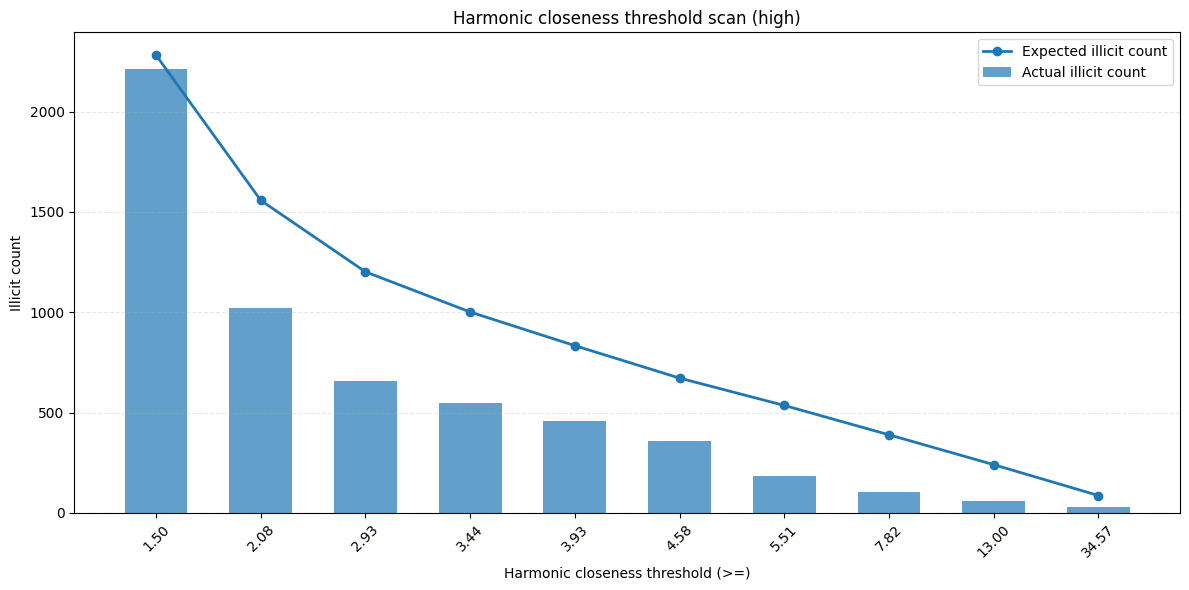

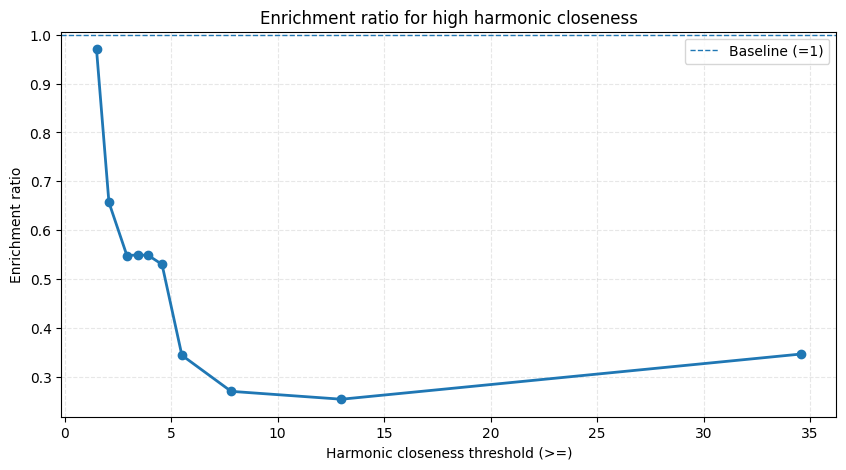

In [68]:
# STEP 18 - PLOT HIGH HARMONIC SCAN

fig, ax = plt.subplots(figsize=(12, 6))

x = range(len(harmonic_scan_high_df))

ax.bar(
    x,
    harmonic_scan_high_df["actual_illicit_count"],
    width=0.6,
    alpha=0.7,
    label="Actual illicit count"
)

ax.plot(
    x,
    harmonic_scan_high_df["expected_illicit_count"],
    marker="o",
    linewidth=2,
    label="Expected illicit count"
)

ax.set_xticks(list(x))
ax.set_xticklabels([f"{t:.2f}" for t in harmonic_scan_high_df["threshold"]], rotation=45)
ax.set_xlabel("Harmonic closeness threshold (>=)")
ax.set_ylabel("Illicit count")
ax.set_title("Harmonic closeness threshold scan (high)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    harmonic_scan_high_df["threshold"],
    harmonic_scan_high_df["enrichment_ratio"],
    marker="o",
    linewidth=2
)

ax.axhline(1, linestyle="--", linewidth=1, label="Baseline (=1)")
ax.set_xlabel("Harmonic closeness threshold (>=)")
ax.set_ylabel("Enrichment ratio")
ax.set_title("Enrichment ratio for high harmonic closeness")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.show()

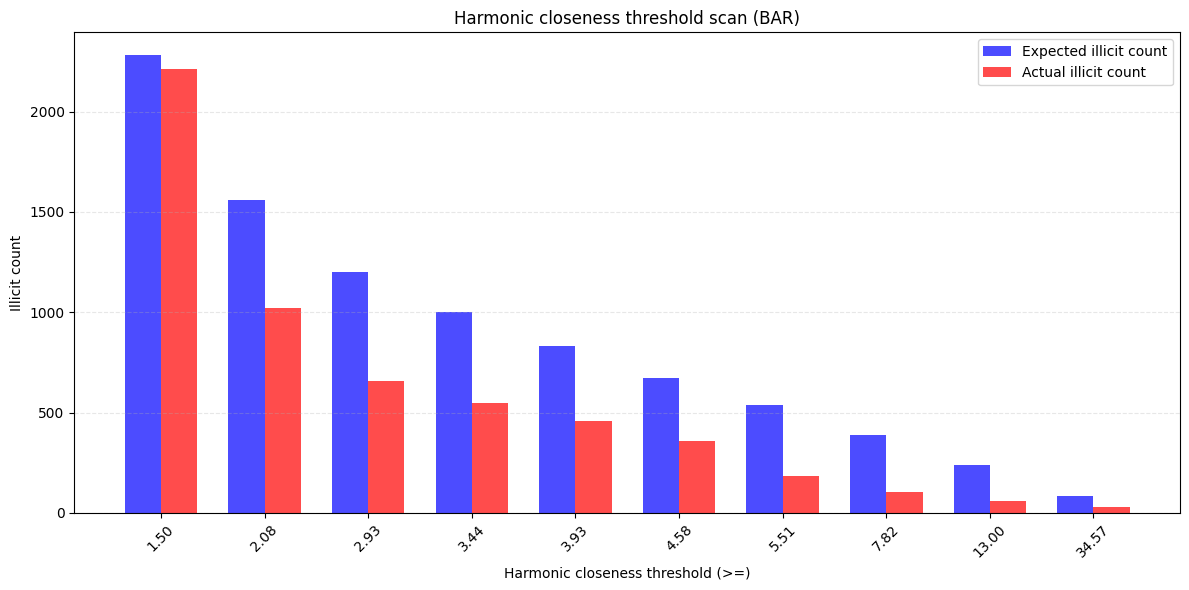

In [69]:
# STEP 18A - BAR CHART (EXPECTED vs ACTUAL)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(harmonic_scan_high_df))
width = 0.35

# Expected (màu xanh)
ax.bar(
    x - width/2,
    harmonic_scan_high_df["expected_illicit_count"],
    width=width,
    color="blue",
    alpha=0.7,
    label="Expected illicit count"
)

# Actual (màu đỏ)
ax.bar(
    x + width/2,
    harmonic_scan_high_df["actual_illicit_count"],
    width=width,
    color="red",
    alpha=0.7,
    label="Actual illicit count"
)

ax.set_xticks(x)
ax.set_xticklabels([f"{t:.2f}" for t in harmonic_scan_high_df["threshold"]], rotation=45)

ax.set_xlabel("Harmonic closeness threshold (>=)")
ax.set_ylabel("Illicit count")
ax.set_title("Harmonic closeness threshold scan (BAR)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

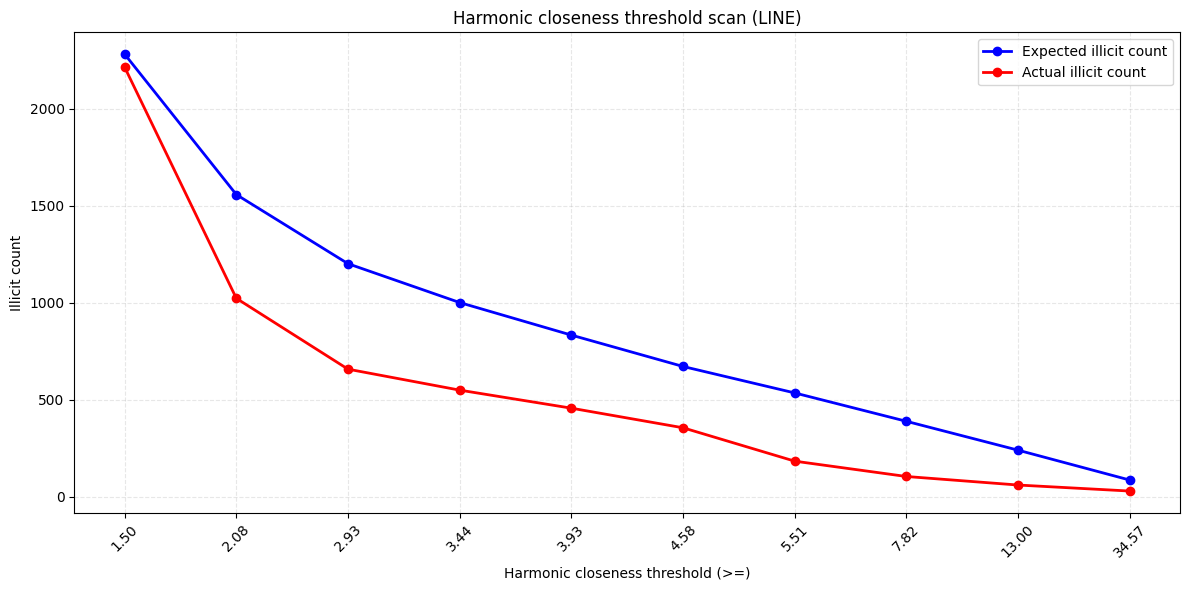

In [70]:
# STEP 18B - LINE CHART (EXPECTED vs ACTUAL)

fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(harmonic_scan_high_df))

# Expected (màu xanh)
ax.plot(
    x,
    harmonic_scan_high_df["expected_illicit_count"],
    marker="o",
    linewidth=2,
    color="blue",
    label="Expected illicit count"
)

# Actual (màu đỏ)
ax.plot(
    x,
    harmonic_scan_high_df["actual_illicit_count"],
    marker="o",
    linewidth=2,
    color="red",
    label="Actual illicit count"
)

ax.set_xticks(x)
ax.set_xticklabels([f"{t:.2f}" for t in harmonic_scan_high_df["threshold"]], rotation=45)

ax.set_xlabel("Harmonic closeness threshold (>=)")
ax.set_ylabel("Illicit count")
ax.set_title("Harmonic closeness threshold scan (LINE)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# STEP 21 - DEFINE TOP-PERCENT SCAN FUNCTION

In [71]:
# STEP 21 - DEFINE TOP-PERCENT SCAN FUNCTION

def scan_top_percent(
    df,
    metric_col,
    top_pcts,
    class_col=CLASS_LABEL_COL,
    positive_label="illicit",
    baseline=0.0
):
    results = []

    metric_series = df[metric_col].dropna()

    for p in top_pcts:
        cutoff = metric_series.quantile(1 - p)
        subset = df[df[metric_col] >= cutoff].copy()

        stats = enrichment_ratio(
            subset,
            class_col=class_col,
            positive_label=positive_label,
            baseline=baseline
        )

        stats["top_pct"] = p
        stats["cutoff"] = cutoff
        stats["rule"] = f"{metric_col} >= Q{100 * (1 - p):.1f} cutoff"
        stats["metric"] = metric_col
        stats["n_subset_total"] = len(subset)
        results.append(stats)

    return pd.DataFrame(results)

# STEP 22 - SCAN BETWEENNESS ENRICHMENT

In [72]:
# STEP 22 - SCAN TOP BETWEENNESS PERCENTILES

betweenness_scan_df = scan_top_percent(
    ps2_df,
    metric_col="betweenness",
    top_pcts=TOP_PCTS,
    class_col=CLASS_LABEL_COL,
    positive_label="illicit",
    baseline=baseline_illicit
)

display(betweenness_scan_df)

,n_subset_labeled,actual_illicit_count,expected_illicit_count,illicit_rate_subset,baseline_illicit_rate,enrichment_ratio,lift_count,top_pct,cutoff,rule,metric,n_subset_total
0,46564,4545,4545.000000,0.097608,0.097608,1.000000,0.000000,0.100,0.000000e+00,betweenness >= Q90.0 cutoff,betweenness,203769
1,597,1,58.271734,0.001675,0.097608,0.017161,-57.271734,0.050,2.944540e-08,betweenness >= Q95.0 cutoff,betweenness,10223
2,23,0,2.244975,0.000000,0.097608,0.000000,-2.244975,0.020,5.840004e-07,betweenness >= Q98.0 cutoff,betweenness,4079
3,2,0,0.195215,0.000000,0.097608,0.000000,-0.195215,0.010,1.374118e-06,betweenness >= Q99.0 cutoff,betweenness,2047
4,1,0,0.097608,0.000000,0.097608,0.000000,-0.097608,0.005,2.267295e-06,betweenness >= Q99.5 cutoff,betweenness,1021


# STEP 23 - PLOT TOP BETWEENNESS SCAN

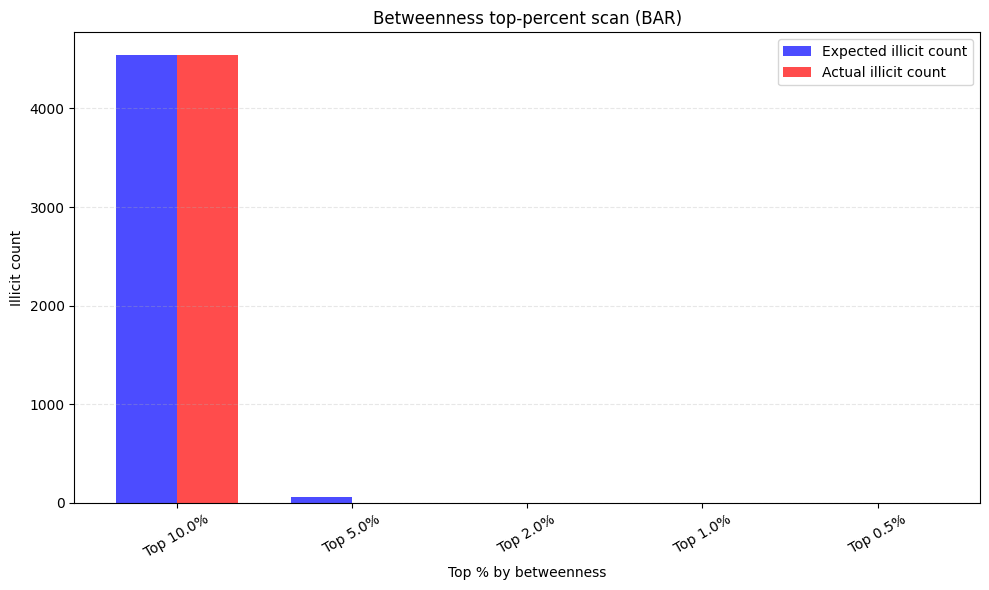

In [73]:
# STEP 23A - BAR CHART (BETWEENNESS: EXPECTED vs ACTUAL)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(betweenness_scan_df))
width = 0.35

# Expected (xanh)
ax.bar(
    x - width/2,
    betweenness_scan_df["expected_illicit_count"],
    width=width,
    color="blue",
    alpha=0.7,
    label="Expected illicit count"
)

# Actual (đỏ)
ax.bar(
    x + width/2,
    betweenness_scan_df["actual_illicit_count"],
    width=width,
    color="red",
    alpha=0.7,
    label="Actual illicit count"
)

ax.set_xticks(x)
ax.set_xticklabels([f"Top {100 * p:.1f}%" for p in betweenness_scan_df["top_pct"]], rotation=30)

ax.set_xlabel("Top % by betweenness")
ax.set_ylabel("Illicit count")
ax.set_title("Betweenness top-percent scan (BAR)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

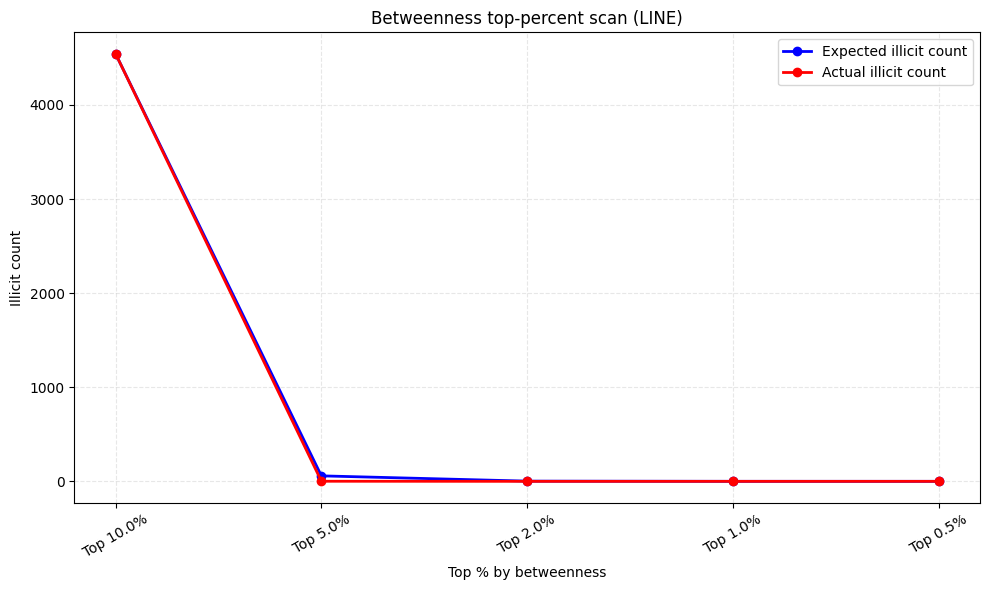

In [74]:
# STEP 23B - LINE CHART (BETWEENNESS: EXPECTED vs ACTUAL)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(betweenness_scan_df))

# Expected (xanh)
ax.plot(
    x,
    betweenness_scan_df["expected_illicit_count"],
    marker="o",
    linewidth=2,
    color="blue",
    label="Expected illicit count"
)

# Actual (đỏ)
ax.plot(
    x,
    betweenness_scan_df["actual_illicit_count"],
    marker="o",
    linewidth=2,
    color="red",
    label="Actual illicit count"
)

ax.set_xticks(x)
ax.set_xticklabels([f"Top {100 * p:.1f}%" for p in betweenness_scan_df["top_pct"]], rotation=30)

ax.set_xlabel("Top % by betweenness")
ax.set_ylabel("Illicit count")
ax.set_title("Betweenness top-percent scan (LINE)")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# STEP 24 - RUN STATISTICAL TESTS

In [75]:


def mannwhitney_with_rbc(df, metric_col, class_col=CLASS_LABEL_COL):
    sub = df[df[class_col].isin(["licit", "illicit"])][[metric_col, class_col]].dropna()

    x = sub.loc[sub[class_col] == "illicit", metric_col].values
    y = sub.loc[sub[class_col] == "licit", metric_col].values

    u_stat, p_value = mannwhitneyu(x, y, alternative="two-sided")
    rbc = (2 * u_stat) / (len(x) * len(y)) - 1

    return {
        "metric": metric_col,
        "n_illicit": len(x),
        "n_licit": len(y),
        "u_stat": u_stat,
        "p_value": p_value,
        "rank_biserial_corr": rbc,
        "median_illicit": np.median(x),
        "median_licit": np.median(y),
        "mean_illicit": np.mean(x),
        "mean_licit": np.mean(y)
    }

mw_betweenness = mannwhitney_with_rbc(ps2_df, "betweenness")
mw_harmonic = mannwhitney_with_rbc(ps2_df, "harmonic_closeness")

mw_results_df = pd.DataFrame([mw_betweenness, mw_harmonic])
display(mw_results_df)

,metric,n_illicit,n_licit,u_stat,p_value,rank_biserial_corr,median_illicit,median_licit,mean_illicit,mean_licit
0,betweenness,4545,42019,92992932.0,6.389221e-24,-0.026131,0.0,0.0,3.347295e-11,2.291157e-09
1,harmonic_closeness,4545,42019,89861774.5,2.536106e-11,-0.058923,1.0,1.5,2.293839e+00,4.304558e+00


# STEP 25 - COMPUTE BETWENNESS PERCENTILES

In [76]:


ps2_df["betweenness_percentile"] = ps2_df["betweenness"].rank(pct=True, method="average")

labeled_ps2 = ps2_df[ps2_df[CLASS_LABEL_COL].isin(["licit", "illicit"])].copy()

median_pct_illicit = labeled_ps2.loc[
    labeled_ps2[CLASS_LABEL_COL] == "illicit", "betweenness_percentile"
].median()

median_pct_licit = labeled_ps2.loc[
    labeled_ps2[CLASS_LABEL_COL] == "licit", "betweenness_percentile"
].median()

print("Median betweenness percentile of illicit nodes:", round(median_pct_illicit, 6))
print("Median betweenness percentile of licit nodes:", round(median_pct_licit, 6))

Median betweenness percentile of illicit nodes: 0.46882
Median betweenness percentile of licit nodes: 0.46882


# STEP 27 - PLOT CROSS-METRIC RELATIONSHIPS

/tmp/ipykernel_55/629584100.py:7: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(min(len(x), 5000), random_state=42))


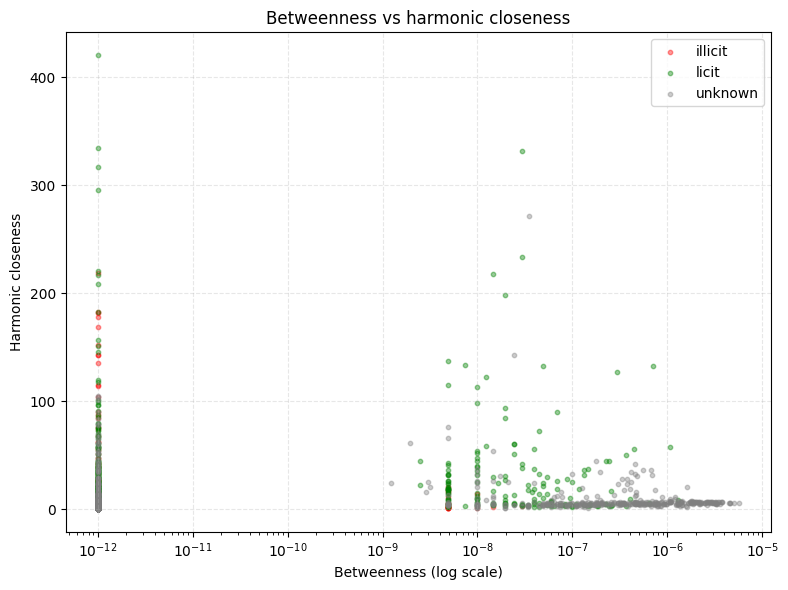

In [77]:
# STEP 27 - PLOT CROSS-METRIC RELATIONSHIPS

plot_df = ps2_df[ps2_df[CLASS_LABEL_COL].isin(["licit", "illicit", "unknown"])].copy()

sample_plot = (
    plot_df.groupby(CLASS_LABEL_COL, group_keys=False)
    .apply(lambda x: x.sample(min(len(x), 5000), random_state=42))
    .reset_index(drop=True)
)

sample_plot["betweenness_plot"] = sample_plot["betweenness"] + 1e-12

color_map = {
    "licit": "green",
    "illicit": "red",
    "unknown": "gray"
}

fig, ax = plt.subplots(figsize=(8, 6))

for cls, g in sample_plot.groupby(CLASS_LABEL_COL):
    ax.scatter(
        g["betweenness_plot"],
        g["harmonic_closeness"],
        s=10,
        alpha=0.4,
        label=cls,
        c=color_map.get(cls, "blue")
    )

ax.set_xscale("log")
ax.set_xlabel("Betweenness (log scale)")
ax.set_ylabel("Harmonic closeness")
ax.set_title("Betweenness vs harmonic closeness")
ax.legend()
ax.grid(True, linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# STEP 28 - EXTRACT THE BACKBONE SUBGRAPH


In [78]:
# STEP 28 - EXTRACT THE BACKBONE SUBGRAPH

top_1pct_cutoff = ps2_df["betweenness"].quantile(0.99)

backbone_nodes = ps2_df.loc[ps2_df["betweenness"] >= top_1pct_cutoff, TX_COL].tolist()
backbone_subgraph = G.subgraph(backbone_nodes).copy()

print("Backbone node count:", len(backbone_nodes))
print("Backbone edge count:", backbone_subgraph.number_of_edges())
print("Backbone weakly connected components:", nx.number_weakly_connected_components(backbone_subgraph))

Backbone node count: 2047
Backbone edge count: 2031
Backbone weakly connected components: 16
